# 06. Convergence transpartisane

Ce notebook examine la **convergence transpartisane** : le rapprochement des positionnements discursifs entre familles politiques traditionnellement opposées. On opérationnalise la convergence par la part de textes modérés (score de positionnement en valeur absolue ≤ 1), proches du centre de l’échelle. Les **movers** (ou transfuges) désignent les députés ou les discours dont le positionnement s’écarte notablement de la tendance dominante de leur bloc, signalant un rapprochement potentiel. On analyse la convergence par batch et par bloc, l’évolution mensuelle du discours modéré, et les écarts entre le Centre et les extrêmes.

## Setup et configuration

Les bibliothèques et les deux versions du corpus sont chargés pour l’analyse de la convergence.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from config import PROJECT_ROOT, RESULTS_DIR, FIGURES_DIR, BLOC_COLORS, BLOC_ORDER, EVENTS, BATCH_ORDER, add_events, format_dates

FIG_DIR = Path("../figures")
RES_DIR = Path("../data/results")
FIG_DIR.mkdir(exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib as mpl
mpl.rcParams.update({
    'figure.constrained_layout.use': True,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 11,
})

def save(name):
    plt.savefig(FIG_DIR / f'{name}.png')
    plt.show()

## Chargement du corpus

Le corpus principal et le corpus par fenêtres événementielles sont chargés. La convergence est mesurée à partir du score de positionnement (|score| ≤ 1 pour « modéré »).

In [2]:
from config import CORPUS_V3, CORPUS_V4
df = pd.read_parquet(CORPUS_V3)
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M').astype(str)
df['group'] = df.get('group', df.get('groupe_politique', 'UNKNOWN'))

df_v4 = pd.read_parquet(CORPUS_V4)
df_v4['date'] = pd.to_datetime(df_v4['date'])
df_v4['month'] = df_v4['date'].dt.to_period('M').astype(str)

print(f"Corpus principal : {len(df):,} textes. Corpus par fenêtres événementielles : {len(df_v4):,} textes.")

Corpus principal : 10,774 textes. Corpus par fenêtres événementielles : 5,905 textes.


## Fig 33 : Convergence transpartisane par batch et bloc

La part de discours modéré (|positionnement| ≤ 1) est calculée par batch et par bloc. Une part élevée indique une convergence accrue vers des formulations moins polarisées.

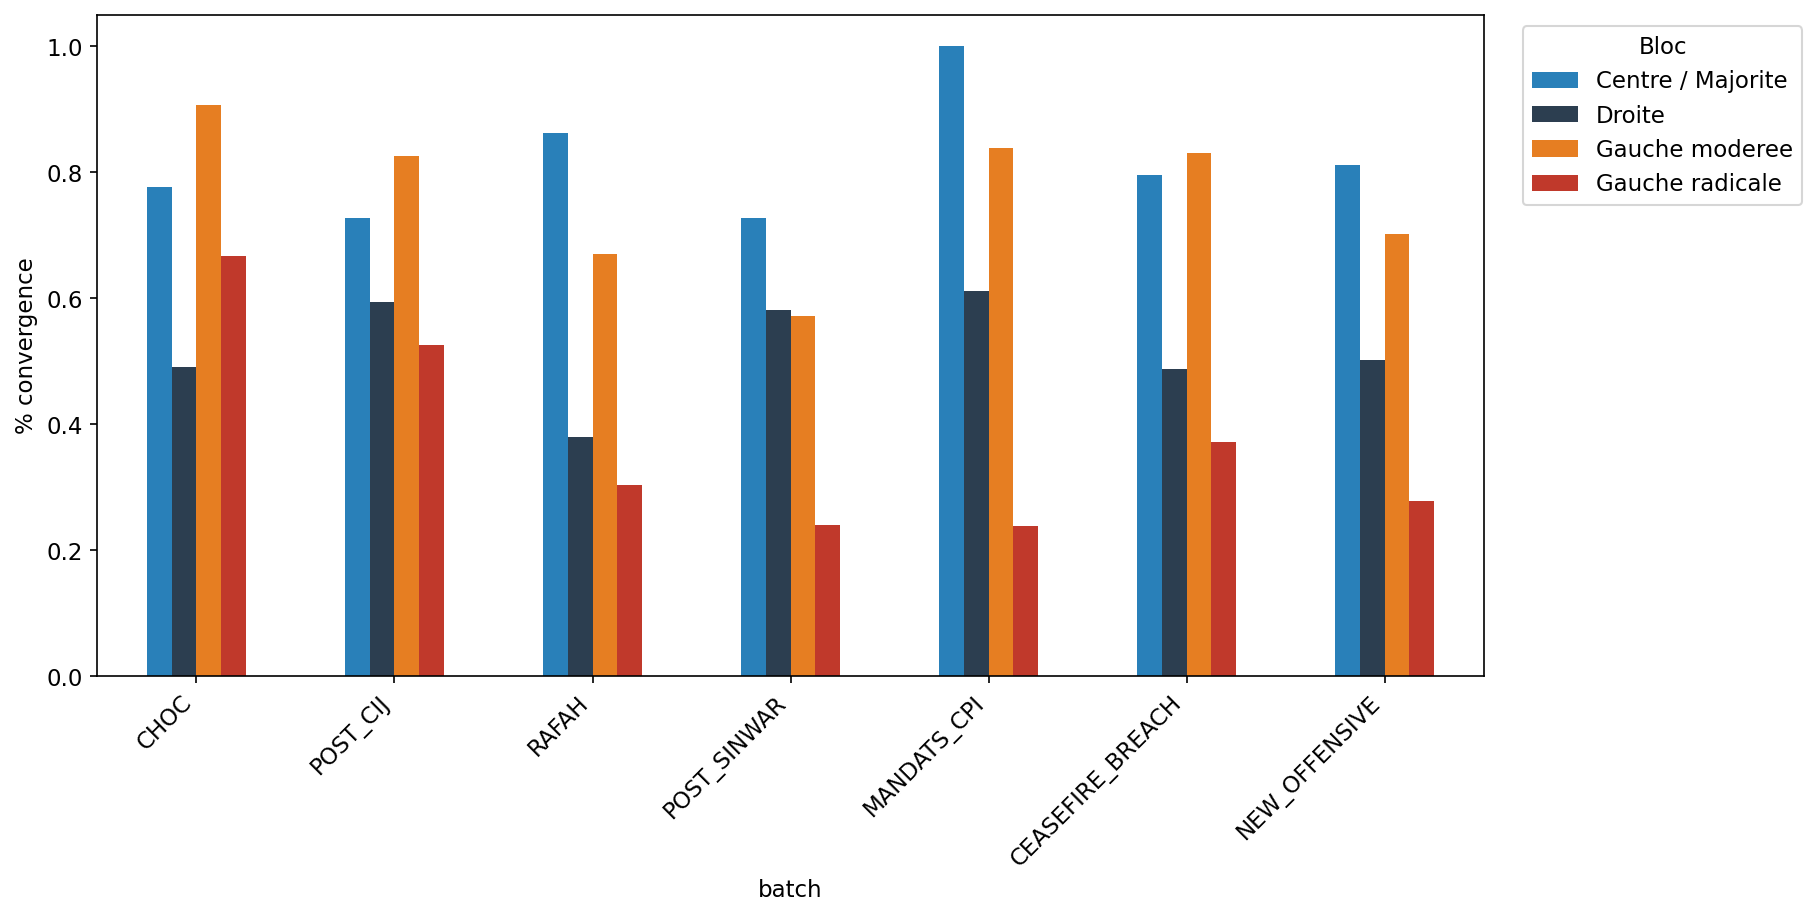

In [3]:
df_conv = df_v4 if 'batch' in df_v4.columns else df.assign(batch=df['month'])
df_conv['convergence'] = (df_conv['stance_v3'].abs() <= 1)
if 'ceasefire_call' in df_conv.columns:
    df_conv['convergence'] = df_conv['convergence'] | df_conv['ceasefire_call']
conv = df_conv.groupby(['batch', 'bloc'])['convergence'].mean().reset_index()
conv.columns = ['batch', 'bloc', 'pct']
conv.to_csv(RES_DIR / 'convergence_batch_bloc.csv', index=False)

if 'batch' in df_conv.columns and conv['batch'].nunique() > 1:
    piv = conv.pivot(index='batch', columns='bloc', values='pct')
    batches_ord = [b for b in BATCH_ORDER if b in piv.index]
    piv = piv.reindex(batches_ord)
    fig, ax = plt.subplots(figsize=(12, 6))
    piv.plot(kind='bar', ax=ax, color=[BLOC_COLORS.get(b, '#888') for b in piv.columns])
    ax.set_ylabel('% convergence')
    plt.xticks(rotation=45, ha='right')
    ax.legend(title='Bloc', bbox_to_anchor=(1.02, 1))
    save('fig33_convergence_batch')
else:
    conv_m = df_conv.groupby(['month', 'bloc']).apply(lambda g: (g['stance_v3'].abs() <= 1).mean()).reset_index()
    conv_m.columns = ['month', 'bloc', 'pct']
    conv_m['month_ts'] = pd.to_datetime(conv_m['month'] + '-01')
    fig, ax = plt.subplots(figsize=(14, 5))
    for bloc in BLOC_ORDER:
        sub = conv_m[conv_m['bloc'] == bloc]
        if len(sub) > 0:
            ax.plot(sub['month_ts'], sub['pct']*100, label=bloc, color=BLOC_COLORS[bloc], lw=2)
    add_events(ax)
    ax.legend()
    ax.set_ylabel('% discours modéré')
    save('fig33_convergence_batch')

La Gauche modérée et le Centre montrent les plus fortes parts de convergence transpartisane lors des batches récents (offensive de Rafah), alors que la Gauche radicale et la Droite restent plus polarisées.

## Fig 35 : Movers cachés (flux par bloc)

L’évolution mensuelle de la part de discours modéré par bloc permet de repérer les inflexions liées aux événements et les trajectoires divergentes selon la famille politique.

C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_5556\3932067577.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mod = df[df['bloc'].isin(BLOC_ORDER)].groupby(['month', 'bloc']).apply(lambda g: (g['stance_v3'].abs() <= 1).mean()).reset_index()


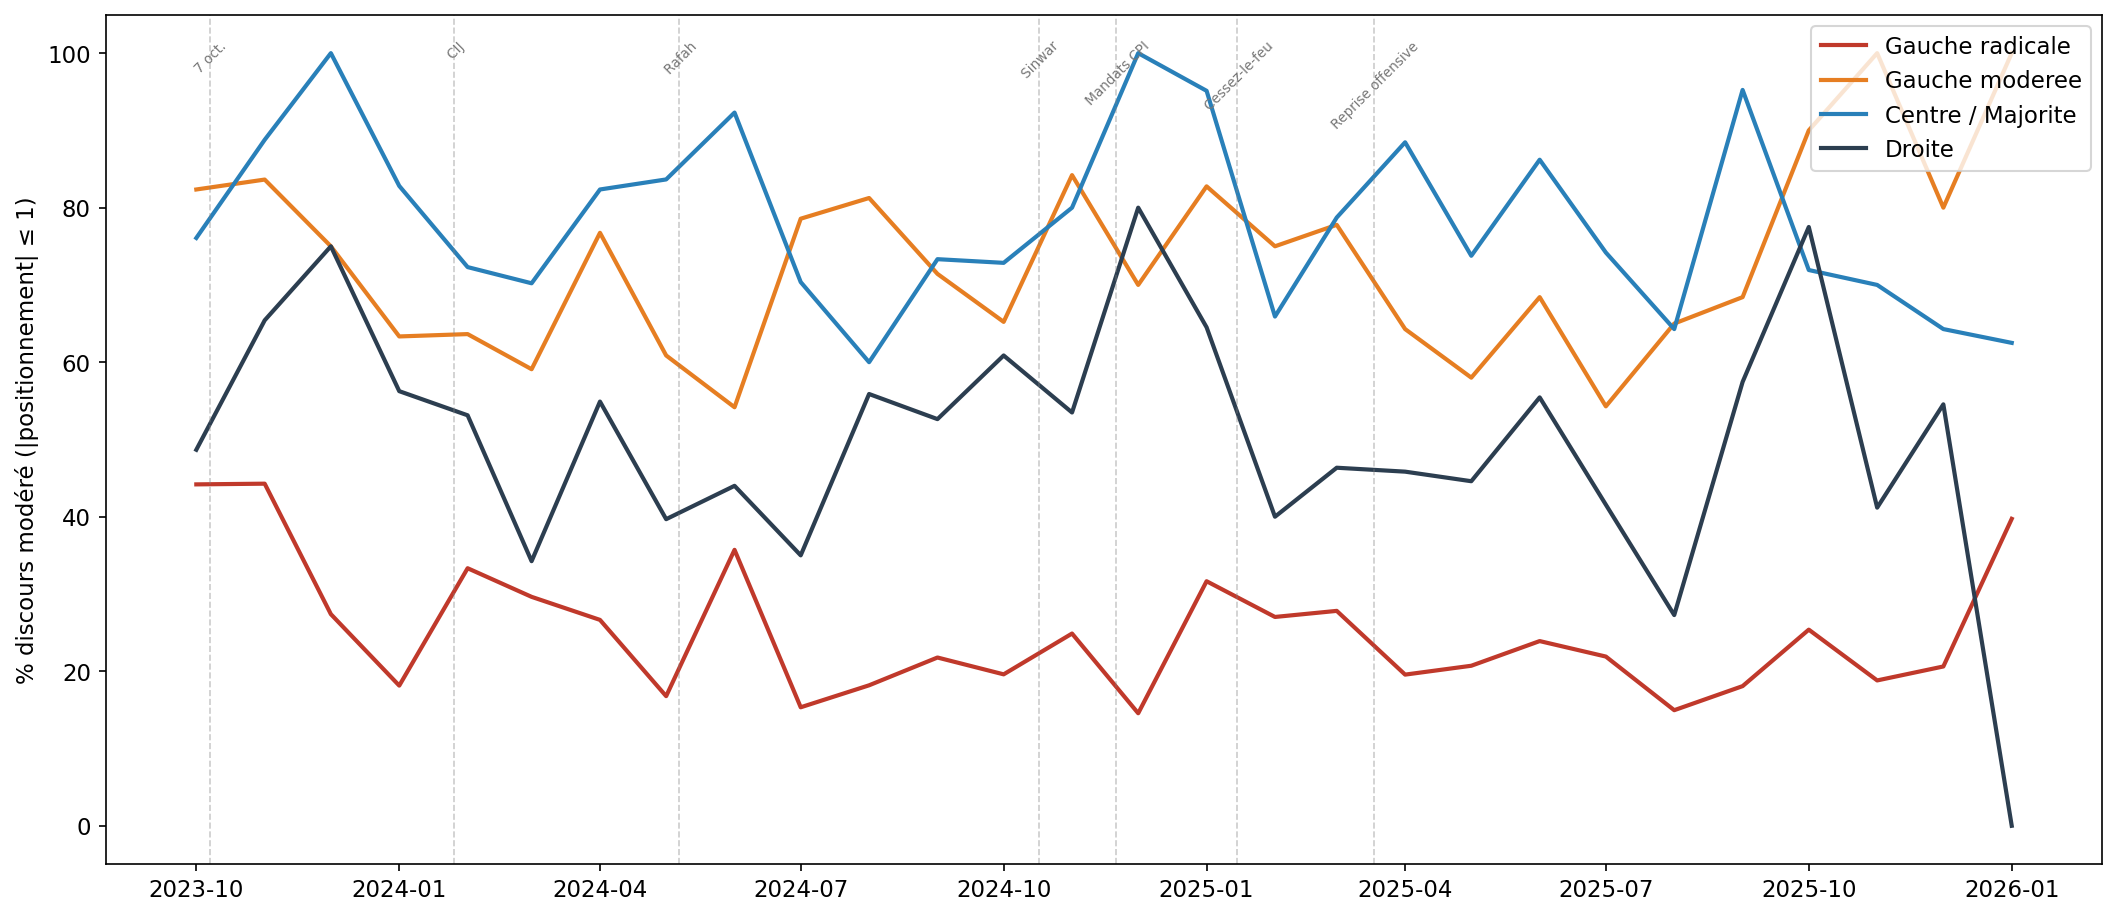

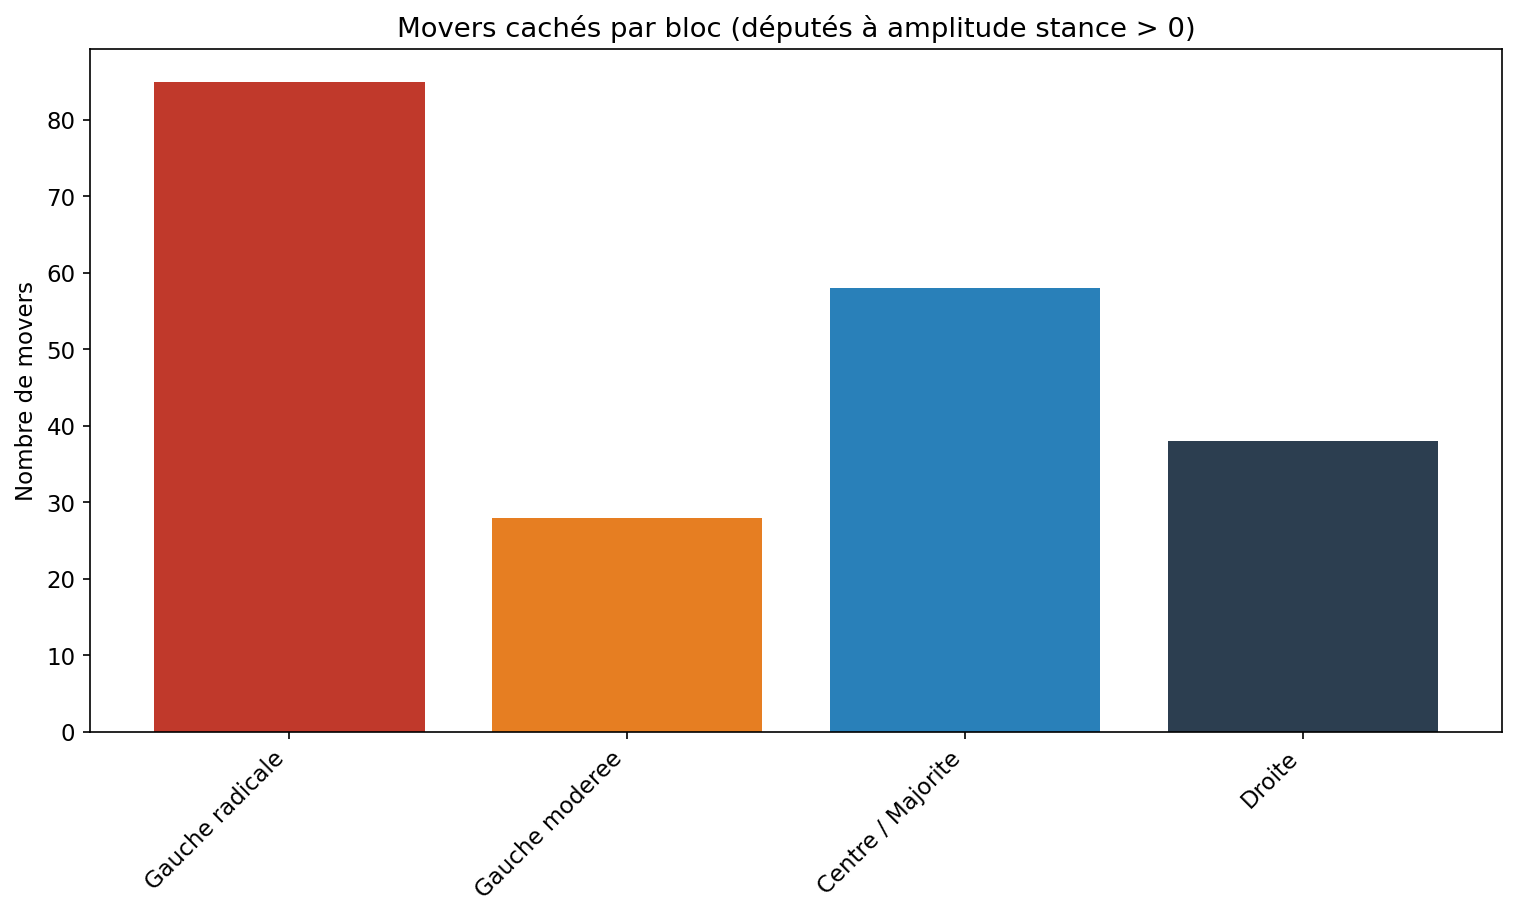

In [4]:
mod = df[df['bloc'].isin(BLOC_ORDER)].groupby(['month', 'bloc']).apply(lambda g: (g['stance_v3'].abs() <= 1).mean()).reset_index()
mod.columns = ['month', 'bloc', 'pct']
mod['month_ts'] = pd.to_datetime(mod['month'] + '-01')

fig, ax = plt.subplots(figsize=(14, 6))
for bloc in BLOC_ORDER:
    sub = mod[mod['bloc'] == bloc]
    if len(sub) > 0:
        ax.plot(sub['month_ts'], sub['pct']*100, label=bloc, color=BLOC_COLORS[bloc], lw=2)
add_events(ax)
ax.legend(loc='upper right')
ax.set_ylabel('% discours modéré (|positionnement| ≤ 1)')
# Évolution mensuelle du discours modéré (conservé)
save('fig34_convergence_mensuelle')
# Fig 35 : Movers cachés (flux par bloc)
movers = pd.read_csv(RES_DIR / "movers_caches.csv")
mover_counts = movers.groupby("bloc").size().reindex(BLOC_ORDER, fill_value=0)
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(len(BLOC_ORDER)), mover_counts.values, color=[BLOC_COLORS.get(b, "#888") for b in BLOC_ORDER])
ax.set_xticks(range(len(BLOC_ORDER)))
ax.set_xticklabels(BLOC_ORDER, rotation=45, ha="right")
ax.set_ylabel("Nombre de movers")
ax.set_title("Movers cachés par bloc (députés à amplitude stance > 0)")
save("fig35_movers_caches")

La part de discours modéré fluctue selon les événements ; le Centre et la Gauche modérée conservent une base plus élevée que les extrêmes.

## Fig 36 : Positionnement moyen par batch (barres groupées)

Le graphique compare le score moyen de positionnement par bloc et par batch, pour visualiser les écarts et les rapprochements entre familles politiques selon les événements.

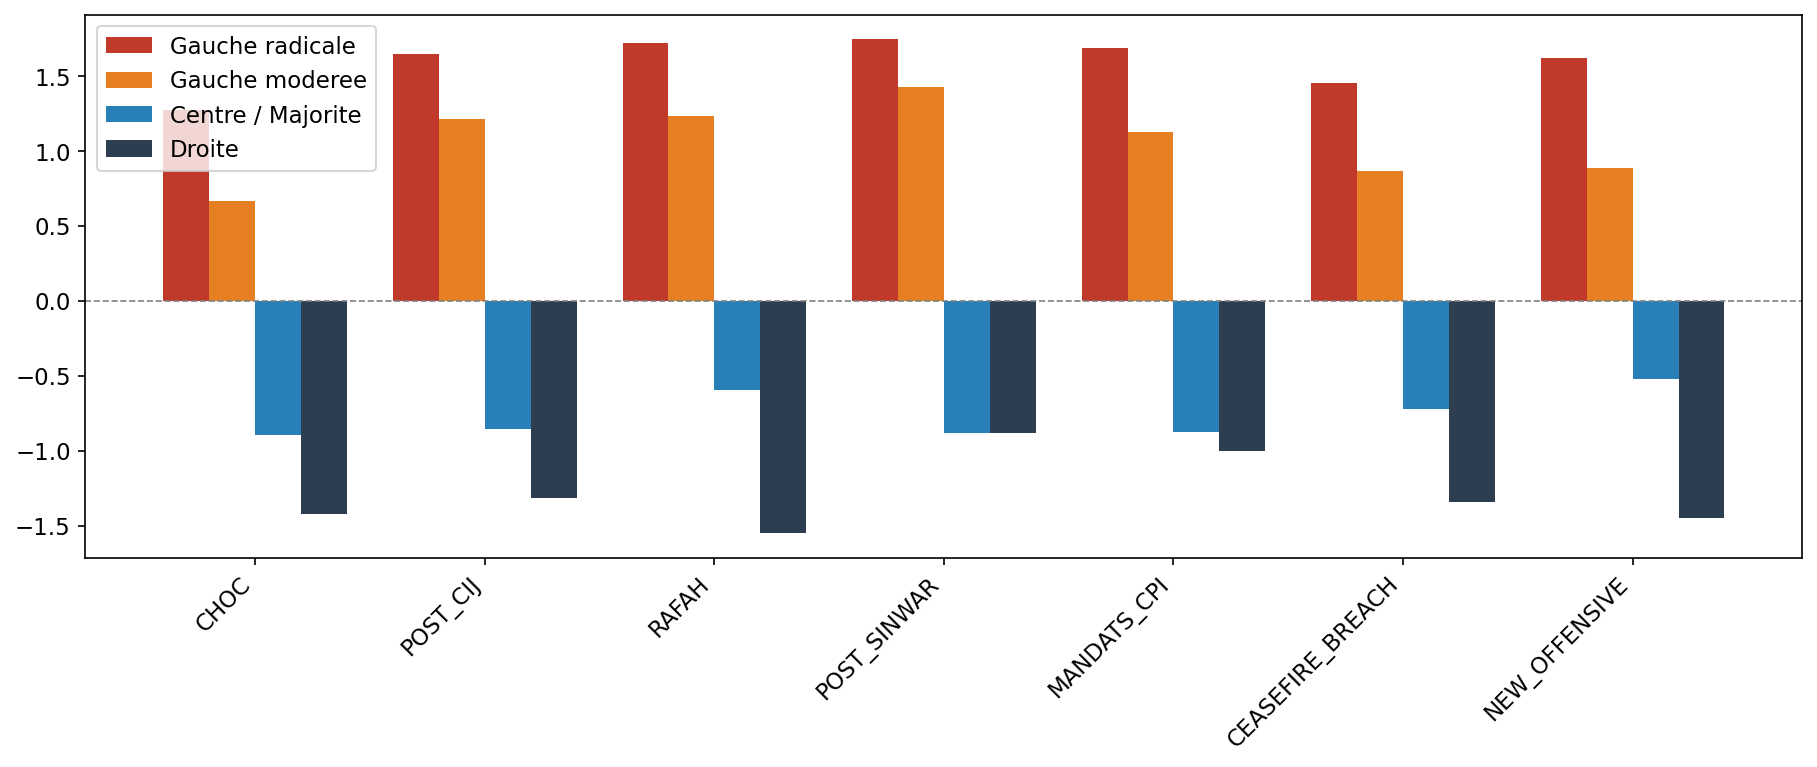

In [5]:
if 'batch' in df_v4.columns:
    sb = df_v4.groupby(['batch', 'bloc'])['stance_v3'].mean().unstack(fill_value=np.nan).reindex(columns=BLOC_ORDER)
    batches = [b for b in BATCH_ORDER if b in sb.index]
    sb = sb.reindex(batches)
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(batches))
    w = 0.2
    for i, bloc in enumerate(BLOC_ORDER):
        if bloc in sb.columns:
            ax.bar(x + (i - 1.5)*w, sb[bloc], w, label=bloc, color=BLOC_COLORS[bloc])
    ax.axhline(0, color='grey', ls='--', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(batches, rotation=45, ha='right')
    ax.legend()
    save('fig36_stance_par_batch')
else:
    save('fig36_stance_par_batch')

## Fig 38 : PCA des députés (TF-IDF, 2 composantes)

Les écarts entre le positionnement moyen du Centre et celui de la Gauche radicale, d’une part, et de la Droite, d’autre part, illustrent la position pivot du Centre et les convergences temporaires suivant les événements juridiques.

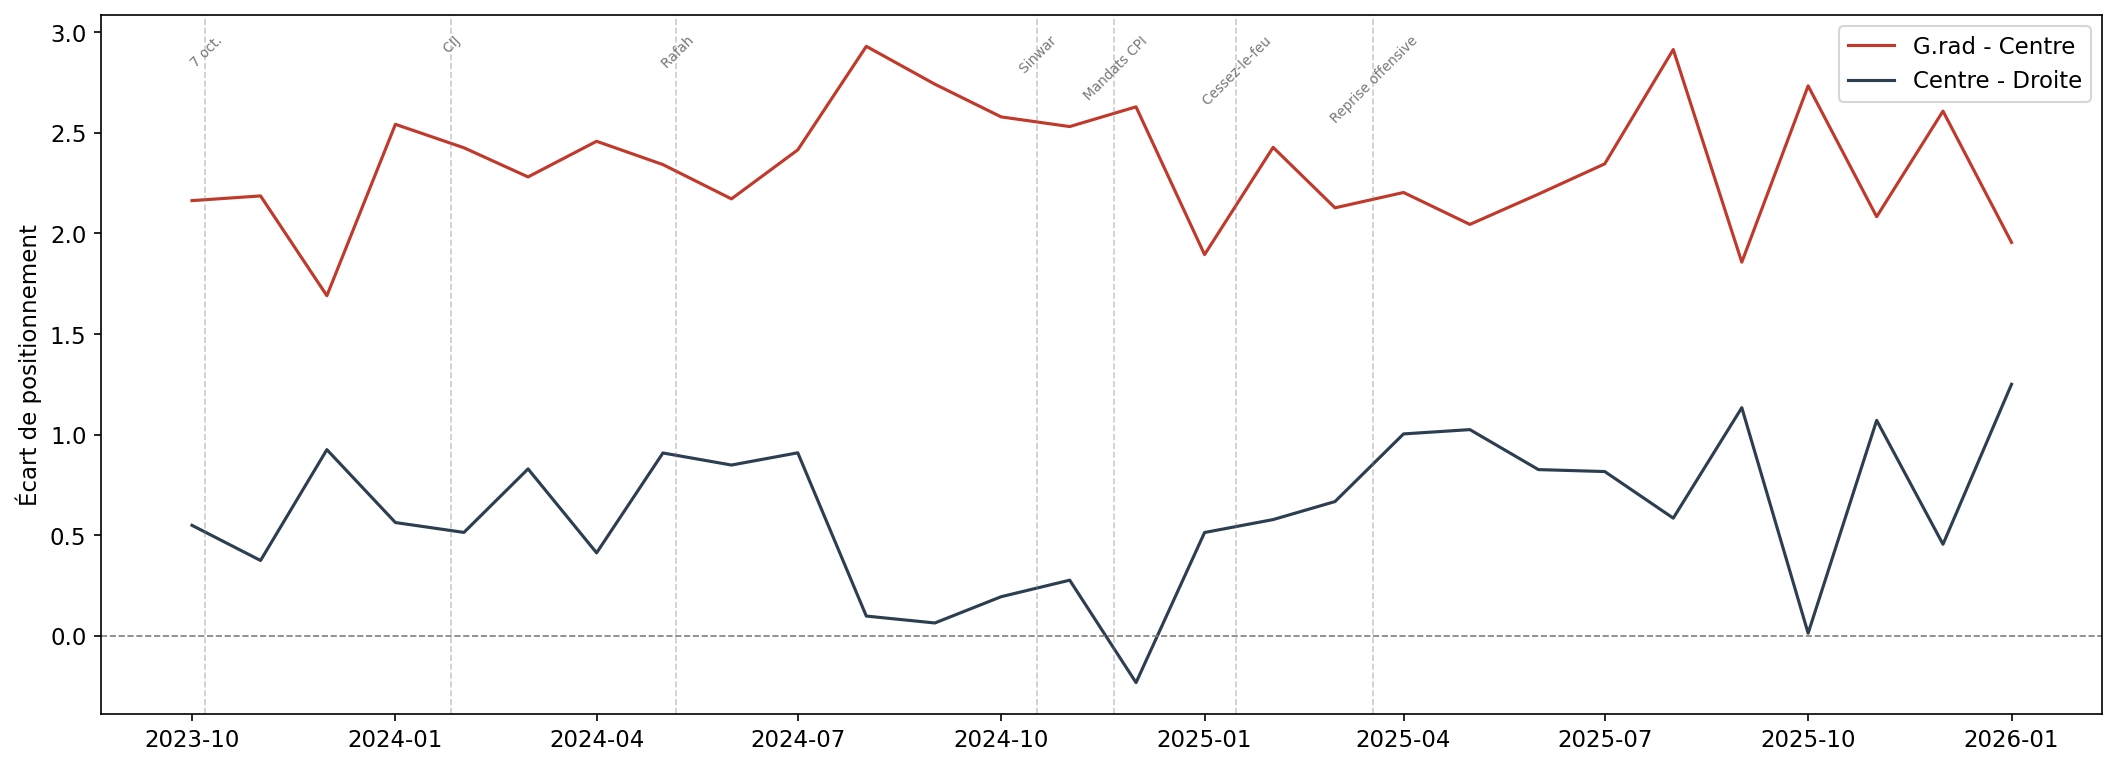

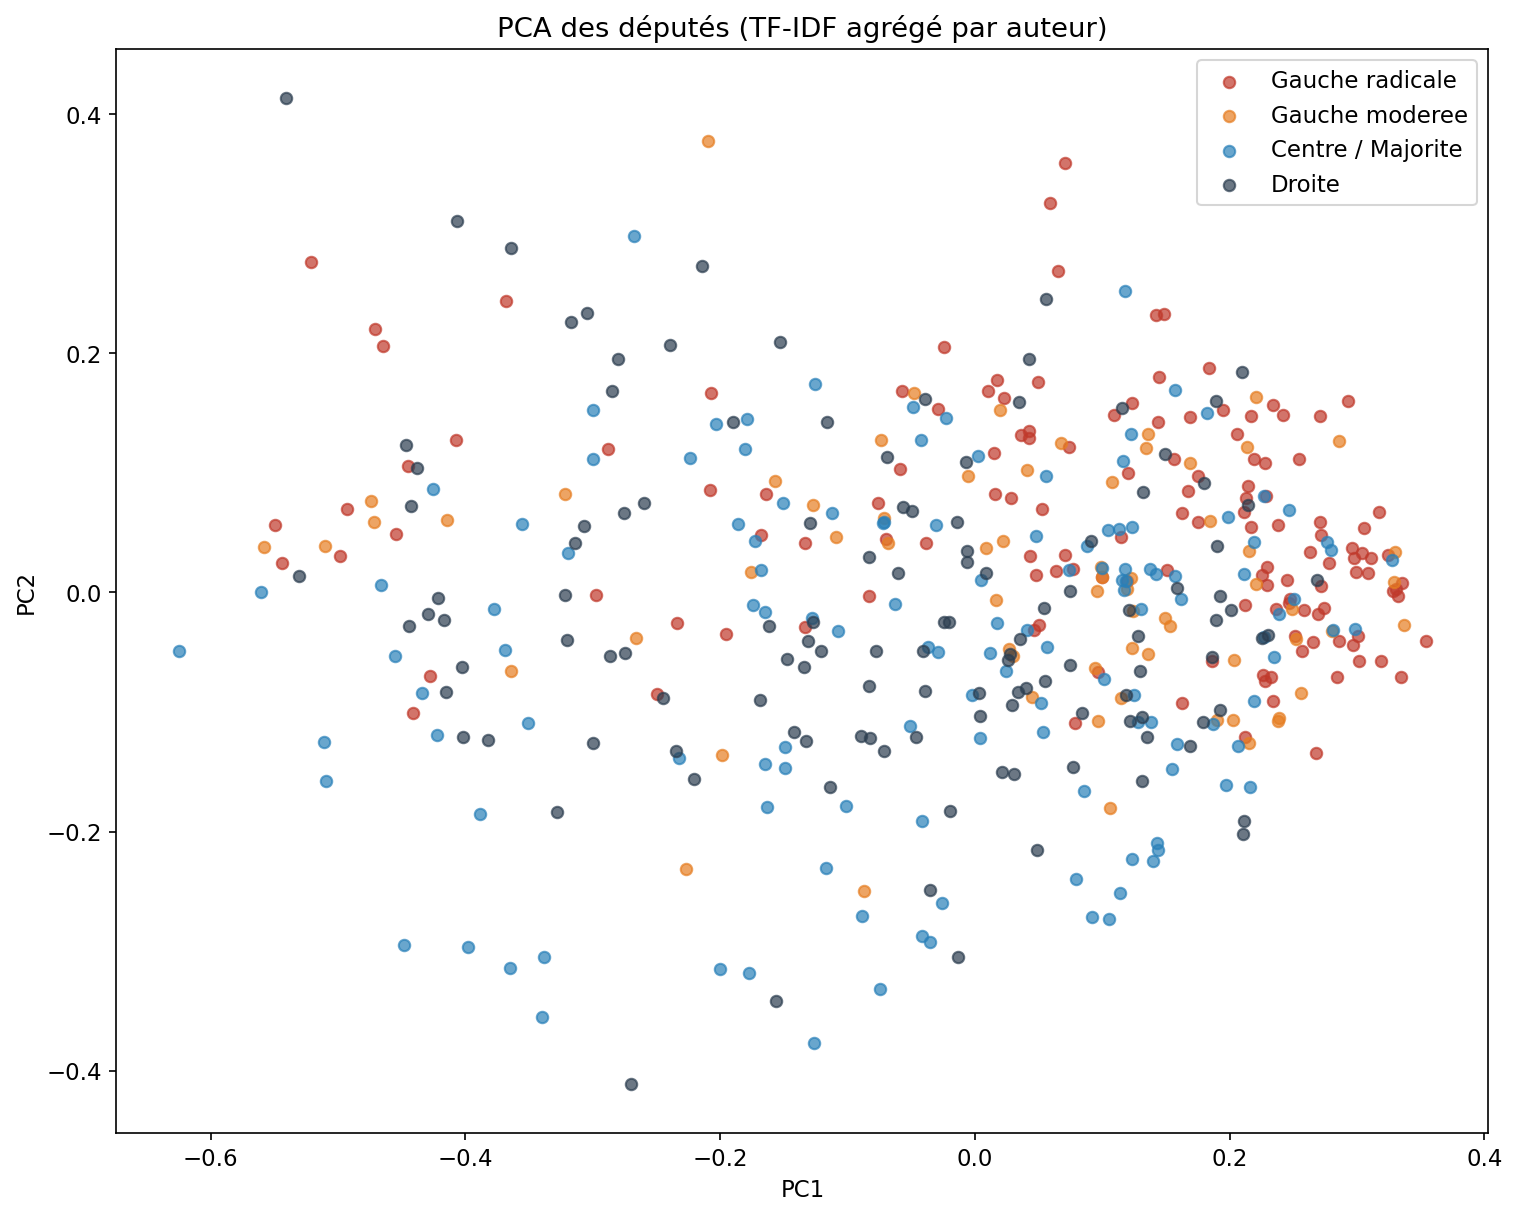

In [6]:
stance_m = df[df['bloc'].isin(BLOC_ORDER)].groupby(['month', 'bloc'])['stance_v3'].mean().unstack(fill_value=np.nan)
stance_m['month_ts'] = pd.to_datetime(stance_m.index.astype(str) + '-01')
col_gr = next((c for c in stance_m.columns if 'radicale' in str(c)), None)
col_c = next((c for c in stance_m.columns if 'Centre' in str(c) or 'Majorite' in str(c)), None)
col_dr = next((c for c in stance_m.columns if 'Droite' in str(c)), None)

fig, ax = plt.subplots(figsize=(14, 5))
if col_gr and col_c:
    ax.plot(stance_m['month_ts'], stance_m[col_gr] - stance_m[col_c], label='G.rad - Centre', color='#c0392b')
if col_c and col_dr:
    ax.plot(stance_m['month_ts'], stance_m[col_c] - stance_m[col_dr], label='Centre - Droite', color='#2c3e50')
add_events(ax)
ax.axhline(0, color='grey', ls='--', lw=0.8)
ax.legend()
ax.set_ylabel('Écart de positionnement')
save('fig37_ecart_centre_extremes')
# Fig 38 : PCA des députés
pca_df = pd.read_csv(RES_DIR / "pca_coordonnees.csv")
fig, ax = plt.subplots(figsize=(10, 8))
for bloc in BLOC_ORDER:
    sub = pca_df[pca_df["bloc"] == bloc]
    if len(sub) > 0:
        ax.scatter(sub["PC1"], sub["PC2"], c=BLOC_COLORS.get(bloc, "#888"), label=bloc, alpha=0.7, s=30)
ax.legend()
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA des députés (TF-IDF agrégé par auteur)")
save("fig38_pca_deputes")

Les écarts entre le Centre et les extrêmes illustrent la position pivot du Centre ; les convergences temporaires suivent les événements juridiques.

## Fig 40 : Portraits de transfuges (3 députés)

La répartition modéré / polarisé par bloc synthétise la part de discours convergent (modéré) versus polarisé pour chaque famille politique.

C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_5556\4269243795.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conv_agg = df.groupby('bloc').apply(lambda g: (g['stance_v3'].abs() <= 1).mean()).reindex(BLOC_ORDER)


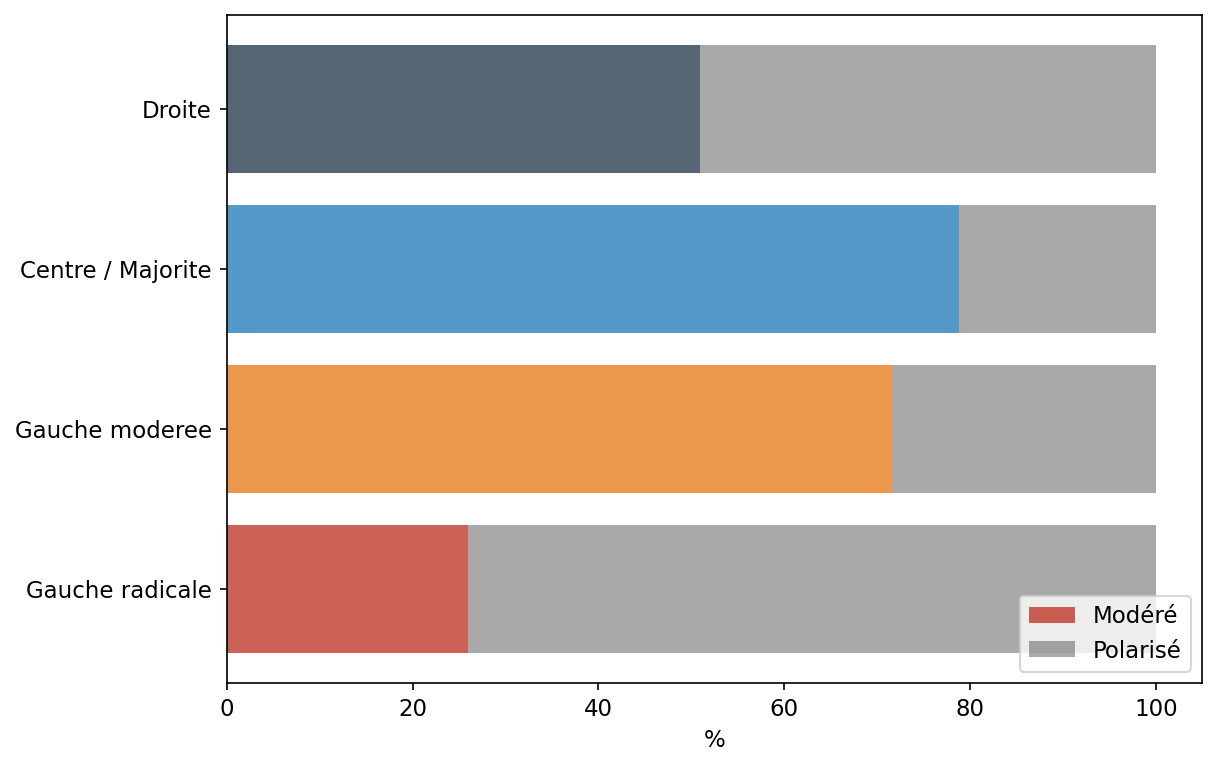

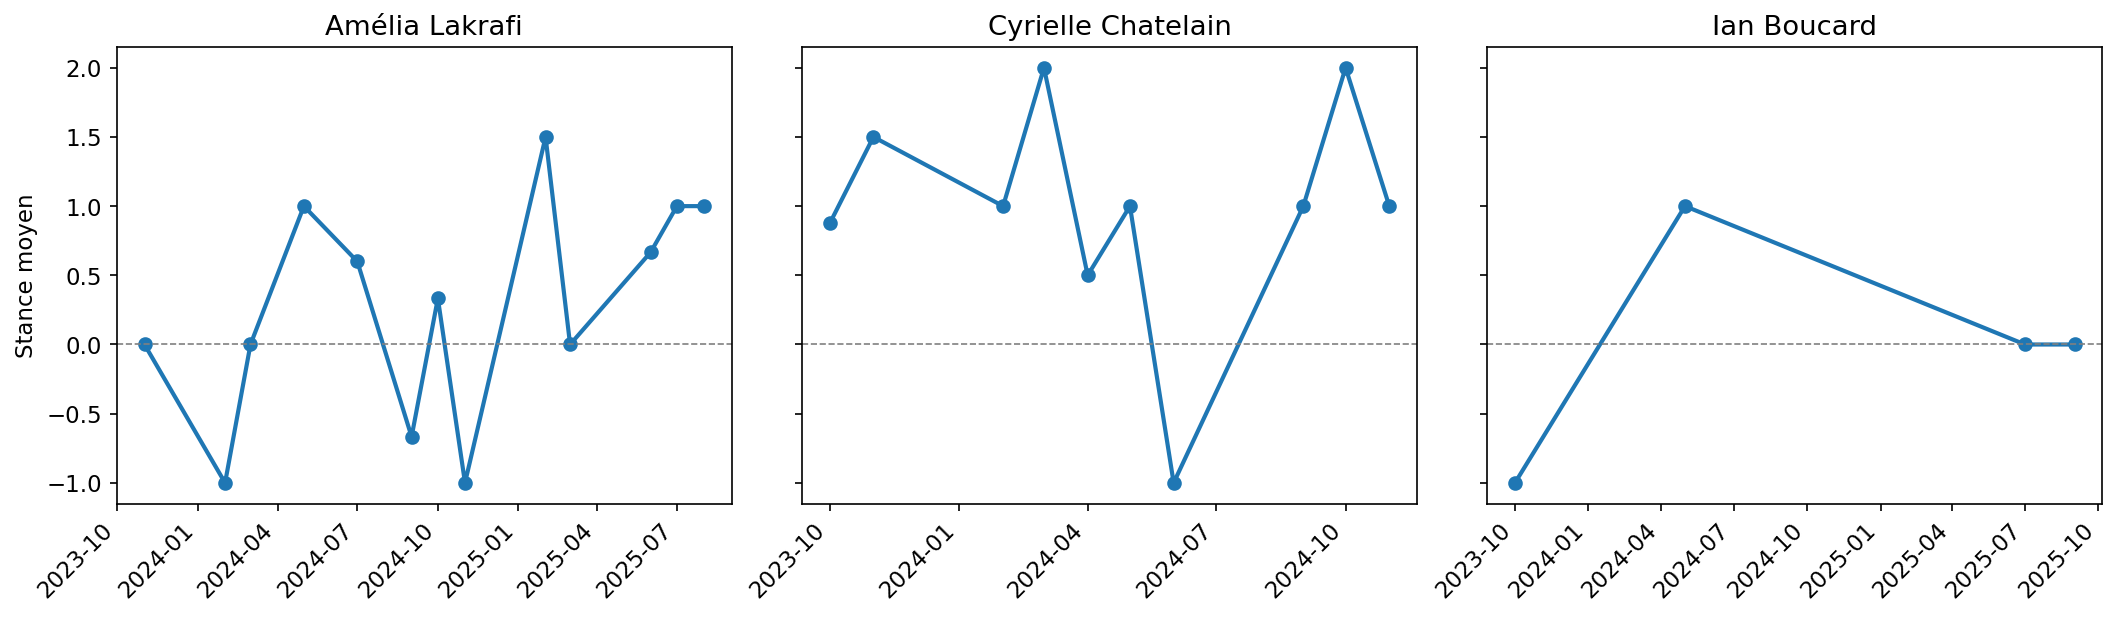

In [7]:
conv_agg = df.groupby('bloc').apply(lambda g: (g['stance_v3'].abs() <= 1).mean()).reindex(BLOC_ORDER)
polar_agg = 1 - conv_agg
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(BLOC_ORDER, conv_agg.values*100, color=[BLOC_COLORS[b] for b in BLOC_ORDER], alpha=0.8, label='Modéré')
ax.barh(BLOC_ORDER, polar_agg.values*100, left=conv_agg.values*100, color=['#555']*4, alpha=0.5, label='Polarisé')
ax.set_xlabel('%')
ax.legend(loc='lower right')
save('fig39_synthese_convergence')
# Fig 40 : Portraits transfuges
TRANSFUGES = ["Amélia Lakrafi", "Cyrielle Chatelain", "Ian Boucard"]
if "author" in df.columns:
    df["month_ts"] = pd.to_datetime(df["month"] + "-01")
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    for ix, name in enumerate(TRANSFUGES):
        sub = df[df["author"] == name]
        if len(sub) > 0:
            agg = sub.groupby("month_ts")["stance_v3"].mean().reset_index()
            ax = axes[ix]
            ax.plot(agg["month_ts"], agg["stance_v3"], "o-", lw=2)
            ax.axhline(0, color="gray", ls="--", lw=0.8)
            ax.set_title(name[:20])
            format_dates(ax)
    axes[0].set_ylabel("Stance moyen")
    save("fig40_portraits_transfuges")

La répartition modéré / polarisé par bloc confirme que le Centre et la Gauche modérée produisent davantage de discours convergent, tandis que les extrêmes restent ancrés dans des positionnements plus marqués.